In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Read new data
df = pd.read_csv('/home/moorche10/Desktop/note_books/divar_new.csv')
df.shape

/tmp/ipykernel_5949/1309079477.py:2: DtypeWarning: Columns (16,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/moorche10/Desktop/note_books/divar_new.csv')


(424442, 37)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424442 entries, 0 to 424441
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                424442 non-null  object 
 1   cat3_slug                424442 non-null  object 
 2   city_slug                424442 non-null  object 
 3   neighborhood_slug        424442 non-null  object 
 4   user_type                424442 non-null  object 
 5   description              424442 non-null  object 
 6   title                    424442 non-null  object 
 7   price_mode               424442 non-null  object 
 8   price_value              424442 non-null  float64
 9   land_size                424442 non-null  float64
 10  building_size            424442 non-null  float64
 11  deed_type                424442 non-null  object 
 12  floor                    424442 non-null  float64
 13  rooms_count              424442 non-null  float64
 14  tota

In [6]:
df.describe()

,price_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,location_latitude,location_longitude
count,4.244420e+05,4.244420e+05,4.244420e+05,424442.000000,424442.000000,424442.000000,424442.000000,424442.000000,424442.000000
mean,1.547958e+10,1.483944e+03,1.085004e+03,2.894167,3.087694,4.981347,2.147504,35.125567,51.563406
std,5.286585e+11,7.627807e+04,6.493766e+04,1.871161,0.841966,1.827631,0.957505,1.755553,2.433289
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000,1.000000,2.000000,1.000000,23.636976,43.774818
25%,1.720000e+09,7.700000e+01,7.500000e+01,2.000000,3.000000,5.000000,2.000000,35.046600,51.020851
50%,3.100000e+09,1.050000e+02,1.000000e+02,3.000000,3.000000,5.000000,2.000000,35.297815,51.546260
75%,6.050000e+09,1.600000e+02,1.370000e+02,3.000000,3.000000,5.000000,2.000000,35.772238,51.546260
max,1.000000e+14,1.000000e+07,1.000000e+07,30.000000,6.000000,30.000000,8.000000,40.358055,62.558594


In [7]:
# Only numeric cols
df=df.drop(["cat2_slug","cat3_slug","city_slug","neighborhood_slug","user_type","description","title",
           "price_mode","deed_type","has_balcony","has_elevator","has_warehouse","has_parking",
           "is_rebuilt","has_water","has_warm_water_provider","has_electricity","has_gas","has_heating_system",
           "has_cooling_system","has_restroom","has_barbecue","building_direction","has_pool","has_jacuzzi",
           "has_sauna","floor_material"],axis=1)
df.shape

(424442, 10)

In [44]:
df=df.drop(["location_latitude","location_longitude"],axis=1)

In [8]:
df["construction_year"].unique()

array(['۱۳۸۴', '۱۴۰۳', '۱۳۹۳', '۱۳۹۶', '۱۳۸۷', '۱۴۰۲', '۱۳۸۸', '۱۳۹۸',
       '۱۴۰۰', '۱۳۹۲', '۱۴۰۱', '۱۳۹۴', '۱۳۸۳', '۱۳۹۹', '۱۳۹۰', '۱۳۸۵',
       '۱۳۸۲', '۱۳۹۵', '۱۳۹۱', '۱۳۸۶', '۱۳۸۰', '۱۳۷۵', '۱۳۹۷', '۱۳۷۲',
       '۱۳۷۴', 'قبل از ۱۳۷۰', '۱۳۸۹', '۱۳۷۹', '۱۳۷۱', '۱۳۸۱', '۱۳۷۳',
       '۱۳۷۸', '۱۳۷۷', '۱۳۷۶'], dtype=object)

In [9]:
df = df[~df["construction_year"].str.contains('قبل از ۱۳۷۰',na=True)]

In [10]:
def persian_to_english_numbers(text):
    if pd.isna(text):
        return text
    persian_numbers = "۰۱۲۳۴۵۶۷۸۹"
    english_numbers = "0123456789"
    translation_table=str.maketrans(persian_numbers,english_numbers)
    return str(text).translate(translation_table)
df["construction_year"]=df["construction_year"].apply(persian_to_english_numbers)
df["construction_year"]=pd.to_numeric(df["construction_year"],errors="coerce")

In [11]:
df["construction_year"].unique()

array([1384, 1403, 1393, 1396, 1387, 1402, 1388, 1398, 1400, 1392, 1401,
       1394, 1383, 1399, 1390, 1385, 1382, 1395, 1391, 1386, 1380, 1375,
       1397, 1372, 1374, 1389, 1379, 1371, 1381, 1373, 1378, 1377, 1376])

In [12]:
df.head()

,price_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,construction_year,location_latitude,location_longitude
0,8.500000e+09,60.0,60.0,3.0,2.0,5.0,2.0,1384,35.046600,51.546260
1,5.750000e+09,115.0,115.0,4.0,3.0,6.0,2.0,1403,35.046600,51.546260
2,8.700000e+09,100.0,100.0,4.0,3.0,5.0,2.0,1393,35.729832,51.505466
3,6.500000e+08,78.0,78.0,4.0,3.0,6.0,4.0,1396,35.712364,50.794781
4,3.000000e+09,80.0,80.0,3.0,3.0,5.0,2.0,1387,35.046600,51.546260


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [45]:
# PCA
# X = df.drop("price_value",axis=1)
# y = df["price_value"]
X = df
y = None
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
pca = PCA(n_components=8).fit(X_scaled)
pca.explained_variance_

array([1.74950972, 1.46025281, 1.15542732, 0.99920664, 0.85929974,
       0.73777081, 0.53979357, 0.49875865])

In [49]:
pca_full = PCA(n_components=8)
pca_full.fit(X_scaled)
cumulative = pca_full.explained_variance_ratio_.cumsum()
for i,cum in enumerate(cumulative,1):
    print(f"{i:2d}kamponent -> {cum:.3%} warianse")
    if cum >= 0.90 :
        print(f"با {i} کامپوننت به واریانس 90% رسیدیم")
        break

 1kamponent -> 21.869% warianse
 2kamponent -> 40.122% warianse
 3kamponent -> 54.565% warianse
 4kamponent -> 67.055% warianse
 5kamponent -> 77.796% warianse
 6kamponent -> 87.018% warianse
 7kamponent -> 93.766% warianse
با 7 کامپوننت به واریانس 90% رسیدیم


In [88]:
pca = PCA(n_components=7)
pca_features = pca.fit_transform(X_scaled)
print('Shape before PCA: ', X_scaled.shape)
print('Shape after PCA: ', pca_features.shape)

Shape before PCA:  (415486, 8)
Shape after PCA:  (415486, 7)


In [89]:
pca_df=pd.DataFrame(
    data=pca_features,
    columns=["PCA1","PCA2","PCA3","PCA4","PCA5","PCA6","PCA7"])
pca_df

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7
0,-0.605722,-0.031070,-1.618150,0.178251,-0.491967,-0.788636,-0.000540
1,0.857434,-0.002608,0.535663,-0.139193,0.714955,-0.472778,-0.000521
2,0.181399,-0.021683,-0.110809,0.012155,-0.304881,-0.516352,0.003453
3,1.558537,-0.005495,-0.911313,0.040654,0.177956,0.844294,0.003002
4,-0.318788,-0.035185,-0.566471,0.093532,-0.836129,-0.240104,0.004063
...,...,...,...,...,...,...,...
415481,1.213979,-0.006211,1.823808,-0.214184,-0.201642,-0.986558,0.004222
415482,-0.445303,-0.021621,0.360347,-0.109574,0.866799,0.509896,-0.002019
415483,-0.326815,-0.033241,-0.405724,0.073398,-0.794347,-0.521703,0.005999
415484,-0.146822,-0.018180,0.391361,-0.111232,0.759535,0.188125,-0.001017


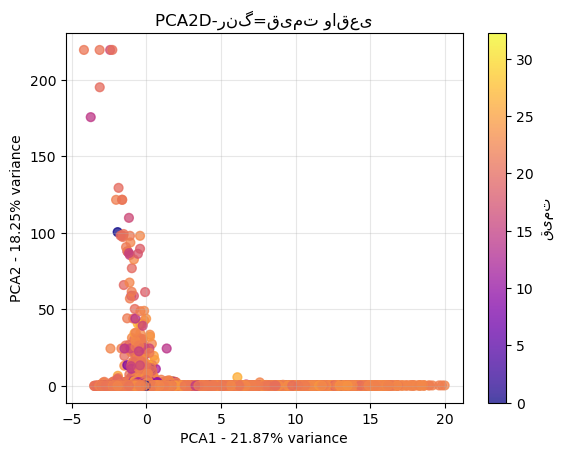

واریانس با دو کامپوننت:93.77%


In [90]:
pca2d = PCA(n_components=7)
x_pca2d = pca2d.fit_transform(X_scaled)
viz_df = pd.DataFrame({
    "PCA1":x_pca2d[:,0],
    "PCA2":x_pca2d[:,1],
    "price":np.log1p(df["price_value"].values)})
plt.figure()
scatter = plt.scatter(viz_df["PCA1"],viz_df["PCA2"],
                      c=viz_df["price"],cmap="plasma",alpha=0.75,s=40)
plt.colorbar(scatter,label="قیمت")
plt.title("PCA2D-رنگ=قیمت واقعی")
plt.xlabel(f"PCA1 - {pca2d.explained_variance_ratio_[0]:.2%} variance")
plt.ylabel(f"PCA2 - {pca2d.explained_variance_ratio_[1]:.2%} variance")
plt.grid(True,alpha=0.3)
plt.show()
print(f"واریانس با دو کامپوننت:{pca2d.explained_variance_ratio_.sum():.2%}")

در حال تست روی 15,000نمونه تصادفی از حدود (500 هزار)


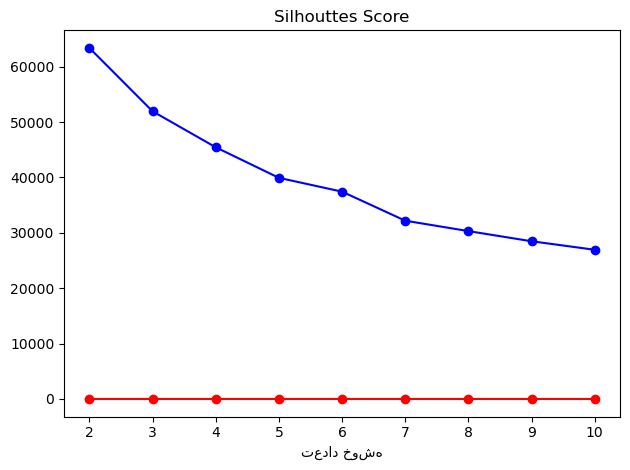


بهترین تعداد خوشه طبق Silouette:2
امتیاز Silhouette:0.6159


In [91]:
from sklearn.metrics import silhouette_score
np.random.seed(10)
sample_size = 15000
idx = np.random.choice(len(x_pca2d),size=sample_size,replace=False)
X_sample = x_pca2d[idx]
print(f"در حال تست روی {sample_size:,}نمونه تصادفی از حدود (500 هزار)")
inertias = []
silhouettes= []
range_n_cluster=range(2,11)

for n in range_n_cluster:
    km = KMeans(n_clusters=n, random_state=10,n_init=5 , algorithm="lloyd")
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample,labels))
    
plt.plot(range_n_cluster,inertias,"bo-")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
# plt.ylabel("inertias")
plt.grid()

plt.plot(range_n_cluster,silhouettes,"ro-")
plt.title("Silhouttes Score")
plt.xlabel("تعداد خوشه")
# plt.ylabel("Score of Silhouttes")
plt.grid()
plt.tight_layout()
plt.show()

best_n = range_n_cluster[np.argmax(silhouettes)]
print(f"\nبهترین تعداد خوشه طبق Silouette:{best_n}")
print(f"امتیاز Silhouette:{max(silhouettes):.4f}")

# best_n_cluster = range_n_cluster[silhouettes.index(max(silhouettes))]
# best_score = max(silhouettes)
# print(f"\nبهترین تعداد خوشه طبق Silouette:{best_n}")
# print(f"امتیاز Silhouette:{best_score:.4f}")
# print(f"(خوشه ها بهترن و جداتر -> هرچی نزدیکتر به 1 باشه)")

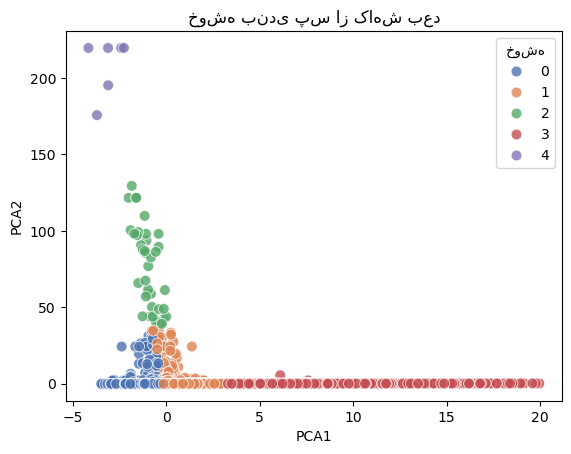

In [60]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,random_state=10)
clusters = kmeans.fit_predict(x_pca2d)
viz_df["Cluster"]=clusters
plt.figure()
sns.scatterplot(data=viz_df,x="PCA1",y="PCA2",hue="Cluster",palette="deep",s=60,alpha=0.8)
plt.title("خوشه بندی پس از کاهش بعد")
plt.legend(title="خوشه")
plt.show()

In [62]:
# Price Value of my Clusters
viz_analyse = viz_df.copy()
viz_analyse["price_real"]=df["price_value"]
print(viz_analyse.groupby("Cluster")["price_real"].agg(["count","mean","std","min","max"]).round(0))

          count          mean           std          min           max
Cluster                                                               
0        189914  1.702952e+10  6.364484e+11          0.0  1.000000e+14
1        206128  1.403678e+10  4.179475e+11          0.0  1.000000e+14
2            42  7.914848e+09  1.934449e+10          0.0  1.200000e+11
3         10609  1.037424e+10  1.785318e+11          0.0  1.111111e+13
4             6  2.517685e+09  1.379126e+09  111111111.0  4.250000e+09


In [69]:
# Best Variance and n_components
pca_final = PCA(n_components=0.92)
X_pca = pca_final.fit_transform(X_scaled)
print(f"تعداد کامپوننت انتخاب شده :{pca_final.n_components_}")
print(f"واریانس حفظ شده : {pca_final.explained_variance_ratio_.sum():.3%}")

تعداد کامپوننت انتخاب شده :7
واریانس حفظ شده : 93.766%


In [86]:
best_n_clusters = 2
kmeans_final = KMeans(n_clusters=best_n_clusters,random_state=10,n_init=10)
clusters = kmeans_final.fit_predict(X_pca)
X_final = pd.DataFrame(X_pca,
                       columns=[f"PCA{i+1}"for i in range(pca_final.n_components_)])
X_final["Cluster"] = clusters.astype(str)
y= df["price_value"].copy()
print(f"دیتافریم نهایی آماده شد")
print(f"شکل :{X_final.shape}")
print(f"ستونها :{list(X_final.columns)}")
print(f"مقادیر یکتای ستون Cluster :{X_final["Cluster"].unique()}")
X_final.head()

دیتافریم نهایی آماده شد
شکل :(415486, 8)
ستونها :['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'Cluster']
مقادیر یکتای ستون Cluster :['0' '1']


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,Cluster
0,-0.605722,-0.031070,-1.618150,0.178251,-0.491967,-0.788636,-0.000540,0
1,0.857434,-0.002608,0.535663,-0.139193,0.714955,-0.472778,-0.000521,0
2,0.181399,-0.021683,-0.110809,0.012155,-0.304881,-0.516352,0.003453,0
3,1.558537,-0.005495,-0.911313,0.040654,0.177956,0.844294,0.003002,0
4,-0.318788,-0.035185,-0.566471,0.093532,-0.836129,-0.240104,0.004063,0


In [96]:
idx = np.random.choice(len(X_pca),30000,replace=False)
X_sample = X_pca[idx]
for k in range(2,10):
    km = KMeans(n_clusters=k,random_state=10,n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample,labels)
    print(f"k={k} -> Silhouette = {score:.4f}")

k=2 -> Silhouette = 0.9834
k=3 -> Silhouette = 0.6026
k=4 -> Silhouette = 0.6036
k=5 -> Silhouette = 0.2585
k=6 -> Silhouette = 0.2599
k=7 -> Silhouette = 0.2768
k=8 -> Silhouette = 0.2801
k=9 -> Silhouette = 0.2700


In [97]:
print("شکل X_pca:",X_pca.shape)

شکل X_pca: (415486, 7)


In [100]:
idx = np.random.choice(len(X_pca),30000,replace=False)
X_sample = X_pca[idx]
for k in range(2,10):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample,labels)
    print(f"k={k} -> Silhouette = {score:.4f}")

k=2 -> Silhouette = 0.6115
k=3 -> Silhouette = 0.2569
k=4 -> Silhouette = 0.2584
k=5 -> Silhouette = 0.2588
k=6 -> Silhouette = 0.2773
k=7 -> Silhouette = 0.2777
k=8 -> Silhouette = 0.2719
k=9 -> Silhouette = 0.2717


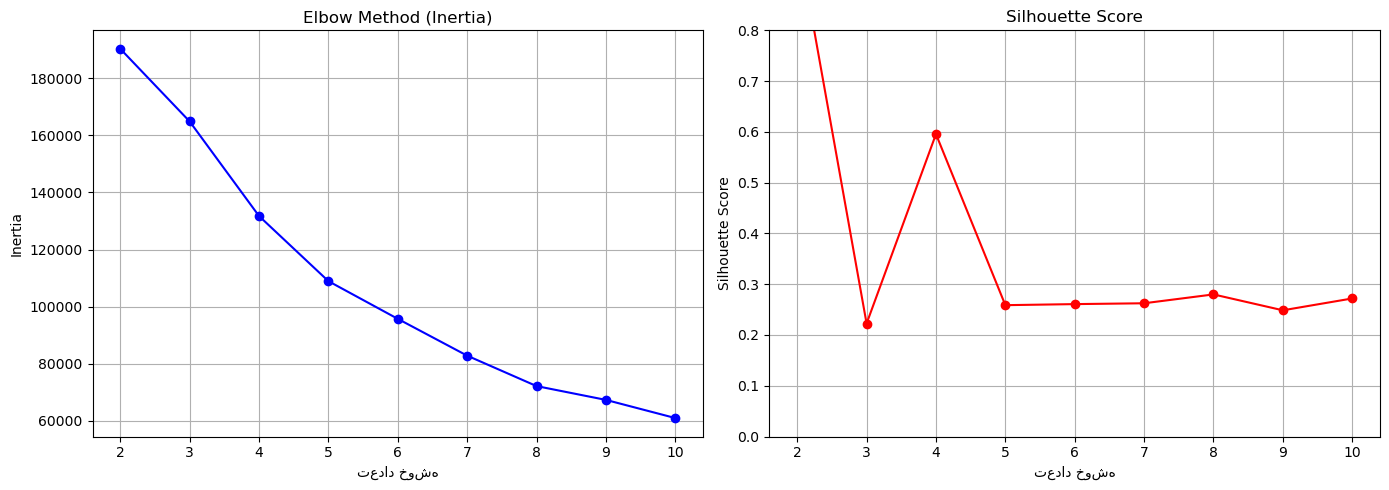

k=2 → Silhouette = 0.9866
k=3 → Silhouette = 0.2225
k=4 → Silhouette = 0.5956
k=5 → Silhouette = 0.2587
k=6 → Silhouette = 0.2608
k=7 → Silhouette = 0.2624
k=8 → Silhouette = 0.2799
k=9 → Silhouette = 0.2486
k=10 → Silhouette = 0.2719


In [101]:
# نمونه‌گیری درست
idx = np.random.choice(len(X_pca), 30000, replace=False)
X_sample = X_pca[idx]

inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels))

# دو تا نمودار جدا با مقیاس درست
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ۱. Elbow Method (Inertia)
ax1.plot(k_range, inertias, 'bo-')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('تعداد خوشه')
ax1.set_ylabel('Inertia')
ax1.grid(True)

# ۲. Silhouette Score (مقیاس درست!)
ax2.plot(k_range, sil_scores, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('تعداد خوشه')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)
ax2.set_ylim(0, 0.8)   # مهم! این خط باعث می‌شه اعداد واقعی دیده بشن

plt.tight_layout()
plt.show()

# چاپ عددها
for k, sil in zip(k_range, sil_scores):
    print(f"k={k} → Silhouette = {sil:.4f}")


In [103]:
best_n_clusters = 4
kmeans_final = KMeans(n_clusters=best_n_clusters,random_state=42,n_init=15)
clusters = kmeans_final.fit_predict(X_pca)
X_final = pd.DataFrame(X_pca,
                       columns=[f"PCA{i+1}"for i in range(pca_final.n_components_)])
X_final["Cluster"] = clusters.astype(str)
y= df["price_value"].copy()
print(f"دیتافریم نهایی آماده شد")
print(f"شکل :{X_final.shape}")
print(f"ستونها :{list(X_final.columns)}")
print(f"مقادیر یکتای ستون Cluster :{X_final["Cluster"].unique()}")
print("########################################")
print(f"توزیخ خوشه ها؛:")
print(X_final["Cluster"].value_counts().sort_index())
print(f"\nمقادیر یکتا",sorted(X_final["Cluster"].unique()))
print(f"شکل نهایی دیتافریم:",X_final.shape)
print(f"n\چند ردیف نخست:",X_final.head())
X_final.head()

دیتافریم نهایی آماده شد
شکل :(415486, 8)
ستونها :['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'PCA7', 'Cluster']
مقادیر یکتای ستون Cluster :['0' '1' '3' '2']
########################################
توزیخ خوشه ها؛:
Cluster
0    175521
1    225088
2        36
3     14841
Name: count, dtype: int64

مقادیر یکتا ['0', '1', '2', '3']
شکل نهایی دیتافریم: (415486, 8)
n\چند ردیف نخست:        PCA1      PCA2      PCA3      PCA4      PCA5      PCA6      PCA7  \
0 -0.605722 -0.031070 -1.618150  0.178251 -0.491967 -0.788636 -0.000540   
1  0.857434 -0.002608  0.535663 -0.139193  0.714955 -0.472778 -0.000521   
2  0.181399 -0.021683 -0.110809  0.012155 -0.304881 -0.516352  0.003453   
3  1.558537 -0.005495 -0.911313  0.040654  0.177956  0.844294  0.003002   
4 -0.318788 -0.035185 -0.566471  0.093532 -0.836129 -0.240104  0.004063   

  Cluster  
0       0  
1       1  
2       0  
3       1  
4       0  


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,Cluster
0,-0.605722,-0.031070,-1.618150,0.178251,-0.491967,-0.788636,-0.000540,0
1,0.857434,-0.002608,0.535663,-0.139193,0.714955,-0.472778,-0.000521,1
2,0.181399,-0.021683,-0.110809,0.012155,-0.304881,-0.516352,0.003453,0
3,1.558537,-0.005495,-0.911313,0.040654,0.177956,0.844294,0.003002,1
4,-0.318788,-0.035185,-0.566471,0.093532,-0.836129,-0.240104,0.004063,0


In [105]:
from sklearn.mixture import GaussianMixture
best_n_clusters = 4
gmm = GaussianMixture(n_components = best_n_cluster,
                      covariance_type = "full",
                      random_state=42 , max_iter=300 , n_init=10)
clusters = gmm.fit_predict(X_pca)
X_final = pd.DataFrame(X_pca,columns=[f"PCA{i+1}" for i in range(7)])
X_final["Cluster"] = clusters.astype(int)
print("توزیع خوشه با GMM")
print(X_final["Cluster"].value_counts().sort_index())

توزیع خوشه با GMM
Cluster
0    397154
1     18332
Name: count, dtype: int64
